# Groebner Triangular Solver

In [1]:
import sympy as sp
import numpy as np
from scipy.optimize import root_scalar
from mpmath import mp

mp.dps = 50  # decimali di precisione

def refine_single_variable(poly, var, initial_val):
    """
    Refines a single-variable root using numerical solver.
    
    Args:
        poly: sympy expression in one variable
        var: sympy symbol
        initial_val: initial guess
        
    Returns:
        Refined root (float)
    """
    result = sp.nsolve(poly, var, initial_val, prec=50)  

    return float(result.root)


def solve_groebner_triangular_system(groebner_basis, variables):
    """
    Solves a triangular system of polynomial equations derived from a Groebner basis.
    Implements recursive back-substitution to find all solutions.
    
    Args:
        groebner_basis: List of polynomials in triangular form (highest variable first)
    
    Returns:
        List of solution dictionaries {variable: value}
    """
    if not groebner_basis:
        return [{}]
    
    # Isolate the first polynomial (containing the highest variable)
    current_poly = groebner_basis[0]
    vars_in_poly = current_poly.free_symbols
    
    if not vars_in_poly:
        return []
    
    # Solve for the highest-degree variable in current polynomial
    current_var = [v for v in variables if v in vars_in_poly][-1]
    solutions = sp.Poly(current_poly, current_var).nroots(maxsteps=200)
    solutions = [sol.evalf() if hasattr(sol, 'evalf') else sol for sol in solutions]
    solutions = [r for r in solutions if sp.im(r) == 0]
    
    if not solutions:
        return []
    
    # Process remaining equations recursively
    remaining_basis = groebner_basis[1:]
    all_solutions = []
    
    for sol_val in solutions:
        # Substitute found value into remaining equations
        substituted_basis = [poly.subs(current_var, float(sol_val)) for poly in remaining_basis]
        
        # Recursively solve reduced system
        partial_solutions = solve_groebner_triangular_system(substituted_basis, variables)
        
        # Combine solutions
        for psol in partial_solutions:
            complete_sol = {current_var: sol_val}
            complete_sol.update(psol)
            all_solutions.append(complete_sol)
    
    return all_solutions


def Triangular_Groebner(F, variables, o='grlex'):
    """
    Computes Groebner basis and transforms it into triangular form.
    
    Args:
        F: List of polynomials
        variables: List of variables
        o: Monomial ordering (default: lexicographic)
    
    Returns:
        List of polynomials in triangular form
    """
    G = sp.groebner(F, *variables, order=o)
    A = list(G.fglm('lex'))
    B = A[::-1]  # Reverse to get triangular form

    # Convert to monic polynomials
    for i in range(len(F)):
        monic_poly = sp.Poly(B[i], *variables)
        B[i] = monic_poly / monic_poly.LC()  # Make leading coefficient 1
    
    return B

# Saddle Node Solver with Wigner-3j symbols

In [13]:
def Plot_polynomials(polynomials, N_PC, mu, sigma, Bif, save=False, ls=False):
    """
    Plotta i polinomi usando valutazione vettorizzata.
    Possible values of Bif:
            Saddle
            Transcritical
            Pitchfork
            S
    """
    a = float(mu - sigma)
    b = float(mu + sigma)
    x_vals = np.linspace(a, b, 400)

    fig, ax = plt.subplots(figsize=(10, 6))  # solo un asse

    for poly in polynomials:
        y_vals = poly(x_vals)
        ax.plot(x_vals, y_vals)

    if Bif == "Saddle":
        positivi = x_vals[x_vals > 0]
        if len(positivi) > 0:
            ax.plot(positivi, [math.sqrt(p) for p in positivi], color="black", linestyle=":")
            ax.plot(positivi, [-math.sqrt(p) for p in positivi], color="black", linestyle=":")

    if Bif == "Transcritical":
        ax.plot(x_vals, x_vals, color='black', linestyle=':')
        ax.plot(x_vals, np.zeros_like(x_vals), color='black', linestyle=':')

    if Bif == "Pitchfork":
        positivi = x_vals[x_vals > 0]
        if len(positivi) > 0:
            ax.plot(positivi, [math.sqrt(p) for p in positivi], color="black", linestyle=":")
            ax.plot(positivi, [-math.sqrt(p) for p in positivi], color="black", linestyle=":")
        ax.plot(x_vals, np.zeros_like(x_vals), color='black', linestyle=':')

    if Bif == "S":
        aux_values = np.linspace(a, b, 100)
        x_values = []
        values = []
        for i in aux_values:
            i = float(i)
            x = sp.Symbol("x")
            f = x**3 - x - i
            sols = sp.Poly(f, x).nroots(maxsteps=200)
            for sol in sols:
                if abs(sp.im(sol)) < 1e-10:
                    x_values.append(i)
                    values.append(sp.re(sol))
        ax.scatter(x_values, values, color="black", marker=".", zorder=5, s=5)

    ax.set_xlabel('$\mu$')  # CORRETTO
    ax.set_ylabel('$u$')    # CORRETTO
    ax.grid(True)

    filename = f"{Bif}_bifurcation_plot_NPC_{N_PC}_mu_{float(mu)}_sigma_{float(sigma)}.pdf"
    if ls is True:
        filename = f"Least_squares_{Bif}_bifurcation_plot_NPC_{N_PC}_mu_{float(mu)}_sigma_{float(sigma)}.pdf"
    if save is True:
        fig.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

In [17]:
from sympy.physics.wigner import wigner_3j


# Main system setup
N_PC = 3  # Polynomial cutoff
N = N_PC + 1
Variables = [sp.symbols(f'x{i}') for i in range(N)]
Variables = np.array(Variables)

# Construct matrices using Wigner 3j symbols
matrices = []
for i in range(N):
    A = [[0 for _ in range(N)] for _ in range(N)]
    for j in range(N):
        for k in range(N):
            symbol = sp.physics.wigner.wigner_3j(i, j, k, 0, 0, 0)
            A[j][k] = sp.Rational(2*(symbol**2))
    A = np.matrix(A)
    matrices.append(A)

# Build polynomial system F = V^T M V for each matrix
F = [(Variables @ matrices[i] @ Variables.T).item() for i in range(N)]

# Add constraints
mu = 1
s = sp.Rational(1,5)
F[0] -= 2*mu       # Constraint for x0
F[1] -= sp.Rational(2,3)*s  # Constraint for x1

print("System equations:")
print(F)

# Compute Groebner basis
B = Triangular_Groebner(F, Variables)

print("\nTriangular Gröbner basis (monic):")
for i in range(len(F)):
    print(f"B[{i}] = {B[i]}")

# Solve the triangular system
solutions = solve_groebner_triangular_system(B, Variables)

# Reorder solutions by variable index (x0, x1, x2, x3)
ordered_symbols = [sp.symbols(f'x{i}') for i in range(N)]
ordered_solutions = []
for sol in solutions:
    ordered_sol = {f'x{i}': sol[symbol] for i, symbol in enumerate(ordered_symbols)}
    ordered_solutions.append(ordered_sol)

# Convert to numerical vectors
solutions_vector = []
print("\nGroebner solutions:\n")
for i, sol in enumerate(ordered_solutions):
    print(f"Solution {i+1}:")
    print(sol)
    vec = [sol[f'x{i}'] for i in range(N)]
    solutions_vector.append(vec)
    print("-"*50)

System equations:
[2*x0**2 + 2*x1**2/3 + 2*x2**2/5 + 2*x3**2/7 - 2, 2*x0*x1/3 + x1*(2*x0/3 + 4*x2/15) + 6*x2*x3/35 + x2*(4*x1/15 + 6*x3/35) - 2/15, 2*x0*x2/5 + x1*(4*x1/15 + 6*x3/35) + x2*(2*x0/5 + 4*x2/35) + x3*(6*x1/35 + 8*x3/105), 2*x0*x3/7 + 6*x1*x2/35 + x2*(6*x1/35 + 8*x3/105) + x3*(2*x0/7 + 8*x2/105)]

Triangular Gröbner basis (monic):
B[0] = x3**16 - 84*x3**14/5 + 27195441*x3**12/250000 - 3451756833*x3**10/10000000 + 560977938050481*x3**8/1000000000000 - 1103504907177603*x3**6/2500000000000 + 68938973822640806451*x3**4/500000000000000000 - 61772159221183015479*x3**2/10000000000000000000 + 255352297895279109/1000000000000000000000000
B[1] = x2 - 2863057807643799087914392825000000000000000000000*x3**15/613223749222782625628022555979252986494879073693 + 2283424996760701140988281884375000000000000000000*x3**13/29201130915370601220382026475202523166422813033 - 300319975339995566250631878274400000000000000000*x3**11/595941447252461249395551560718418840131077817 + 450381806829214358843

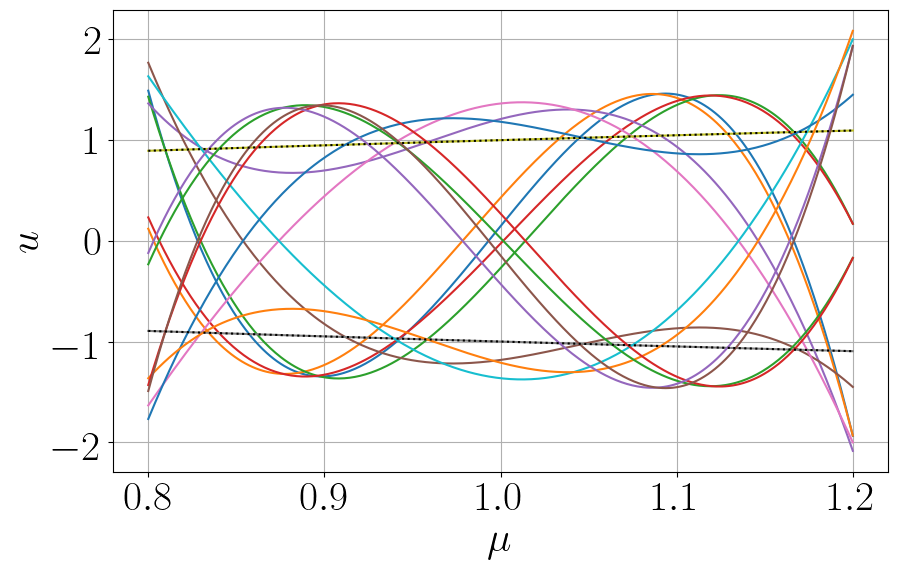

In [18]:
from sympy import legendre
import numpy as np
import sympy as sp
import math
import matplotlib.pyplot as plt

from sympy import legendre, Symbol, lambdify


plt.rcParams.update({
    'font.size': 30,           # Dimensione generale del font
    'axes.titlesize': 30,      # Titolo dell'asse
    'axes.labelsize': 30,      # Etichette degli assi
    'legend.fontsize': 30,     # Legenda
    'xtick.labelsize': 30,     # Etichette asse x
    'ytick.labelsize': 30      # Etichette asse y
})


plt.rcParams['text.latex.preamble']=r"\usepackage{lmodern}"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 30
plt.rcParams['font.family'] = 'lmodern'

def generate_scaled_legendre_polynomials(solutions_vector, N_PC, mu, sigma):
    """
    Constructs callable functions P(x) = sum c_n * P_n((x - mu)/sigma)
    """
    x = Symbol('x')
    scaled_x = (x - mu) / sigma  # map x ∈ [mu-sigma, mu+sigma] to [-1, 1]

    # Precompute scaled Legendre basis
    scaled_legendre_basis = [legendre(n, scaled_x) for n in range(N_PC + 1)]

    polynomials = []
    for coeffs in solutions_vector:
        expr = sum(float(coeffs[n]) * scaled_legendre_basis[n] for n in range(N_PC + 1))
        func = lambdify(x, expr, 'numpy')
        polynomials.append(func)

    return polynomials

# Example use — assuming you've already defined:
# solutions_vector, mu, s, N_PC, and chosen Bif

sigma = s
Bif = "Saddle"  # or "Pitchfork", "Transcritical", "S"
save = True
ls = False

# Step 1: convert Groebner solution vectors to callable functions
polynomials = generate_scaled_legendre_polynomials(solutions_vector, N_PC, mu, sigma)

# Step 2: plot them
Plot_polynomials(polynomials, N_PC, mu, sigma, Bif, save=save, ls=ls)


## Numerical verification

In [14]:
# Numerical verification using scipy.optimize.root
from scipy.optimize import root

print("\nNumerical verification:")
variables_tuple = tuple(Variables)
G = sp.lambdify(variables_tuple, F, "numpy")

def func(vals):
    """Wrapper function for numerical root finding"""
    return G(*vals)

for i, groebner_sol in enumerate(solutions_vector):
    sol = ordered_solutions[i]
    res = 0
    for eq in F:
        res += abs(eq.subs(sol).evalf())        # calculate the 1-norm of the vector of residuals
    
    if res<=10**2:
        numerical_sol = root(func, [float(val) for val in groebner_sol])
        
        print(f"Solution {i+1}:")
        print(f"Groebner:  {groebner_sol}")
        print(f"Groebner residual: {res}")
        print(f"Numerical: {numerical_sol.x}")
        print(f"Residual norm: {np.linalg.norm(numerical_sol.fun)}")
        print("-"*50)


Numerical verification:
Solution 21:
Groebner:  [0.190293481968746, 0.0392273455448174, 1.01514239644061, 1.54442320792896, -1.86795256928839, -0.770400982079895]
Groebner residual: 0.302127586622624
Numerical: [ 0.0997804   0.05506211  1.0162847   1.54454681 -1.86798281 -0.77040098]
Residual norm: 2.3951778881419916e-10
--------------------------------------------------
Solution 22:
Groebner:  [0.0908040666966507, -0.0515572592078365, -0.747400164054773, 1.82208682753181, 1.78054578665289, -0.739964145215787]
Groebner residual: 0.538014609198425
Numerical: [-0.10042815 -0.07918505 -0.7468315   1.82206226  1.78045049 -0.73996415]
Residual norm: 2.343216286595203e-10
--------------------------------------------------
Solution 23:
Groebner:  [0.864132985015488, -0.284193304903114, -0.586699266850681, -0.690499824432602, -0.727708950556579, -0.707008457002292]
Groebner residual: 0.0469040021025972
Numerical: [ 0.8552285  -0.28653644 -0.58662693 -0.69049973 -0.72768111 -0.70700846]
Residu

# Solver with $\mu$ and $\sigma$

In [15]:
import sympy as sp

# Parametri
N_PC = 2
N = N_PC + 1
Variables = sp.symbols(f'x0:{N}')  # (x0, x1, x2, x3)
V = sp.Matrix(Variables)

# Matrici con Wigner 3j
matrices = []
for i in range(N):
    A = sp.Matrix(N, N, lambda j, k: 2 * sp.physics.wigner.wigner_3j(i, j, k, 0, 0, 0)**2)
    matrices.append(A)

# Sistema F = Vᵀ Mᵢ V
F = [(V.T @ matrices[i] @ V)[0] for i in range(N)]

# Vincoli
mu, s = sp.symbols('mu s')
F[0] -= 2*mu
F[1] -= sp.Rational(1, 5)*s

# Output sistema
print("System equations:")
for f in F:
    print(f)

# Base di Gröbner
B = Triangular_Groebner(F, Variables)

# Normalizzazione (monic)
print("\nTriangular Gröbner basis (monic):")
for i in range(len(B)):
    poly = sp.Poly(B[i], *Variables)
    if poly.LC() != 0:
        B[i] = poly / poly.LC()
    print(f"B[{i}] = {B[i]}")


System equations:
-2*mu + 2*x0**2 + 2*x1**2/3 + 2*x2**2/5
-s/5 + 2*x0*x1/3 + 4*x1*x2/15 + x1*(2*x0/3 + 4*x2/15)
2*x0*x2/5 + 4*x1**2/15 + x2*(2*x0/5 + 4*x2/35)

Triangular Gröbner basis (monic):
B[0] = -70*mu*x2**6/9 + 12005*s**4/17915904 + x2**8 + x2**4*(67375*mu**2/3888 + 1225*s**2/6912) + x2**2*(-7503125*mu**3/629856 + 162925*mu*s**2/373248)
B[1] = -22146048*mu*x2**5/(-2058000*mu**2*s + 16807*s**3) + x1 + 13436928*x2**7/(-10290000*mu**2*s + 84035*s**3) + x2**3*(7747200*mu**2 + 71064*s**2)/(-294000*mu**2*s + 2401*s**3) + x2*(-840000*mu**3 + 16580*mu*s**2)/(-42000*mu**2*s + 343*s**3)
B[2] = 161243136*mu*x2**7/(-14406000*mu**2*s**2 + 117649*s**4) + x0 + x2**5*(-895795200*mu**2 - 435456*s**2)/(-10290000*mu**2*s**2 + 84035*s**4) + x2**3*(57024000*mu**3 + 685728*mu*s**2)/(-294000*mu**2*s**2 + 2401*s**4) + x2*(-16800000*mu**4 + 508000*mu**2*s**2 - 987*s**4)/(-126000*mu**2*s**2 + 1029*s**4)
